In [1]:
from src.MILArchitecture.windows import top_windows
from src.visualization.attention_visualization import plot_attention_heatmap_with_two_au

import pandas as pd

In [2]:
df = pd.read_csv("../data/processed/combined.csv")

# ALL AU's
Running the MIL approach with all eight AUs.

Accuracy (Balanced): 0.5817129629629629
Avg. Loss: 0.7684920488229764
              precision    recall  f1-score   support

           0       0.52      0.43      0.47        54
           1       0.66      0.74      0.69        80

    accuracy                           0.61       134
   macro avg       0.59      0.58      0.58       134
weighted avg       0.60      0.61      0.60       134



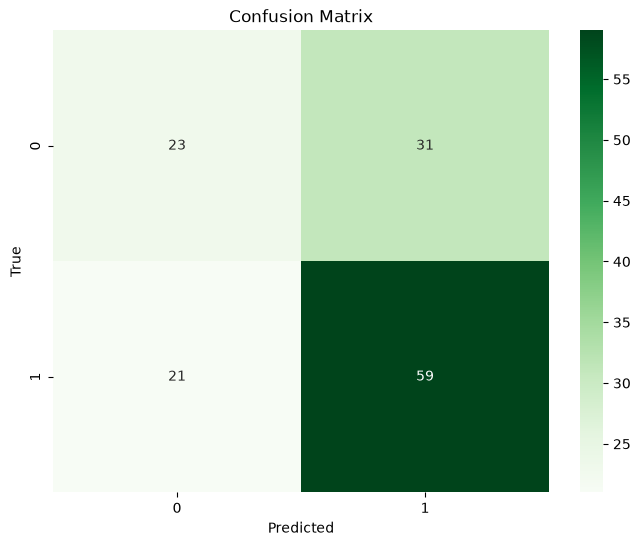

In [3]:
from src.MILArchitecture.full_pipelines import attention_based_mil
from src.utils.data import au_cols

_ = attention_based_mil(df, au_cols)

# AU02/AU12 Pair

Accuracy (Balanced): 0.6189814814814815
Avg. Loss: 0.7047907043905819
              precision    recall  f1-score   support

           0       0.58      0.46      0.52        54
           1       0.68      0.78      0.73        80

    accuracy                           0.65       134
   macro avg       0.63      0.62      0.62       134
weighted avg       0.64      0.65      0.64       134



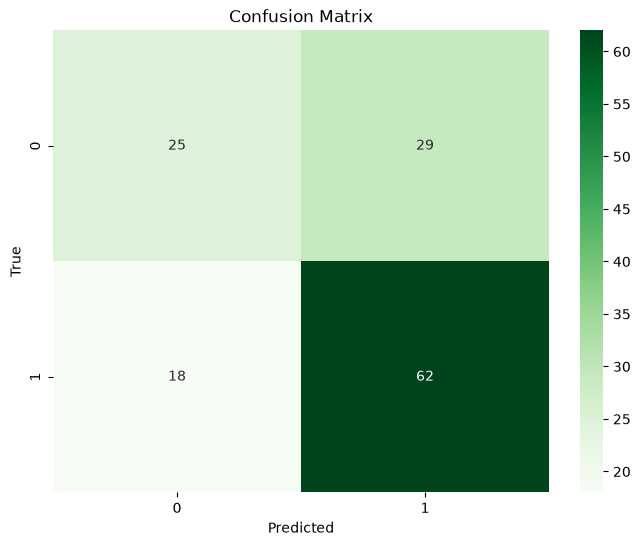

In [4]:
attention_results = attention_based_mil(df, ["AU02_r", "AU12_r"])

# ATTENTION VISUALIZATIONS OF AU02/AU12 Pair

In [5]:
df_attention = pd.DataFrame(attention_results)
df_attention

,clip_id,true_label,pred_prob,pred_label,attention,evidence,contribution,X
0,Art6_S2,1,0.685323,1,"[0.0091224, 0.0091224, 0.0091224, 0.009333276,...","[tensor(-0.1876), tensor(-0.1876), tensor(-0.1...","[tensor(-0.0017), tensor(-0.0017), tensor(-0.0...","[[-0.054545455, -0.44486693], [-0.054545455, -..."
1,Art6_S32,1,0.553007,1,"[0.02369934, 0.023297086, 0.023297086, 0.03281...","[tensor(-0.1824), tensor(-0.1876), tensor(-0.1...","[tensor(-0.0043), tensor(-0.0044), tensor(-0.0...","[[-0.027272727, -0.44486693], [-0.054545455, -..."
2,Art6_S36,1,0.610539,1,"[0.1003709, 0.101975456, 0.07749946, 0.0125489...","[tensor(1.2847), tensor(1.3267), tensor(0.8578...","[tensor(0.1289), tensor(0.1353), tensor(0.0665...","[[10.690909, -0.44486693], [11.036364, -0.4448..."
3,Art6_S43,0,0.534383,1,"[0.018408924, 0.016281629, 0.016281629, 0.0162...","[tensor(-0.1483), tensor(-0.1876), tensor(-0.1...","[tensor(-0.0027), tensor(-0.0031), tensor(-0.0...","[[0.12727273, -0.44486693], [-0.054545455, -0...."
4,Art6_S6,0,0.483701,0,"[0.1710097, 0.07096937, 0.085550815, 0.0906877...","[tensor(0.1048), tensor(-0.1876), tensor(-0.12...","[tensor(0.0179), tensor(-0.0133), tensor(-0.01...","[[1.2, -0.44486693], [-0.054545455, -0.4448669..."
...,...,...,...,...,...,...,...,...
129,Tech21_S32,0,0.572406,1,"[0.2771257, 0.33533147, 0.24178106, 0.14576176]","[tensor(0.2390), tensor(0.3768), tensor(0.1218...","[tensor(0.0662), tensor(0.1264), tensor(0.0295...","[[1.0, 1.1762621], [1.2372881, 1.5695306], [0...."
130,Tech21_S33,0,0.552848,1,"[0.049933415, 0.05611375, 0.06448805, 0.111119...","[tensor(-0.1732), tensor(-0.1067), tensor(-0.0...","[tensor(-0.0086), tensor(-0.0060), tensor(-0.0...","[[0.050847456, 0.14348981], [0.016949153, 0.37..."
131,Tech21_S4,0,0.485553,0,"[0.16243833, 0.17819971, 0.21041784, 0.2107046...","[tensor(-0.2263), tensor(-0.1883), tensor(-0.1...","[tensor(-0.0368), tensor(-0.0336), tensor(-0.0...","[[-0.050847456, -0.111603186], [-0.050847456, ..."
132,Tech21_S5,0,0.483552,0,"[0.22032933, 0.18174994, 0.17869315, 0.2086548...","[tensor(-0.1237), tensor(-0.1857), tensor(-0.1...","[tensor(-0.0273), tensor(-0.0338), tensor(-0.0...","[[0.27118644, 0.29406554], [-0.050847456, 0.06..."


# EXAMPLES - TRUE POSITIVE

In [6]:
true_positives = [
    r for r in attention_results
    if r["true_label"] == 1 and r["pred_label"] == 1
]

true_positives_sorted = sorted(
    true_positives,
    key=lambda r: r["pred_prob"],
    reverse=True
)

for r in true_positives_sorted:
    print(f"{r["clip_id"]}:  {r["pred_prob"]}")

Pol2_S42:  0.9402433037757874
Pol2_S54:  0.9317455887794495
Pol2_S4:  0.9007959365844727
Pol2_S52:  0.8363577723503113
Bus14_S5:  0.8331239819526672
Med15_S98:  0.8209065198898315
Bus14_S2:  0.8147451877593994
Bus14_S18:  0.8038085103034973
Med15_S82:  0.7747470736503601
Bus14_S17:  0.7653082609176636
Phi3_S25:  0.7532065510749817
Med15_S69:  0.7384850382804871
Bus14_S110:  0.7219827771186829
Med15_S68:  0.7114484906196594
Bus14_S48:  0.6997457146644592
Bus14_S113:  0.696158230304718
Pol2_S20:  0.694151759147644
Bus14_S105:  0.6896995902061462
Art6_S2:  0.6853233575820923
Pol2_S125:  0.6625964045524597
Edu2_S78:  0.659966230392456
Pol2_S81:  0.6496433615684509
Tech21_S105:  0.6453191637992859
Art6_S88:  0.6341107487678528
Bus14_S109:  0.6307516694068909
Phi3_S5:  0.627253532409668
Tech10_S84:  0.6163148880004883
Tech10_S53:  0.611014723777771
Art6_S36:  0.6105385422706604
Edu2_S37:  0.6050737500190735
Ent5_S3:  0.5956628322601318
Ent5_S61:  0.5943468809127808
Phi3_S177:  0.578957378864

In [7]:
true_positive_ex1 = df_attention[df_attention["clip_id"] == "Med15_S98"]
true_positive_ex1

,clip_id,true_label,pred_prob,pred_label,attention,evidence,contribution,X
63,Med15_S98,1,0.820907,1,"[0.009065061, 0.006776354, 0.0029656668, 0.002...","[tensor(0.5674), tensor(0.3775), tensor(-0.212...","[tensor(0.0051), tensor(0.0026), tensor(-0.000...","[[3.2142856, -0.39857015], [2.5892856, -0.3985..."


In [8]:
top_attention_windows = top_windows(true_positive_ex1)
top_attention_windows.to_csv("../results/attention_heatmaps/true_positive_ex1.csv", float_format="%.4f")
top_attention_windows

,window,start_time_seconds,end_time_seconds,attention_weight,evidence,contribution
0,103,17.000000,17.333333,0.058471,3.117844,0.182305
1,101,16.666667,17.000000,0.057527,3.128548,0.179977
2,85,14.000000,14.333333,0.054260,2.890128,0.156818
3,102,16.833333,17.166667,0.054185,2.753706,0.149209
4,105,17.333333,17.666667,0.053619,2.617962,0.140373


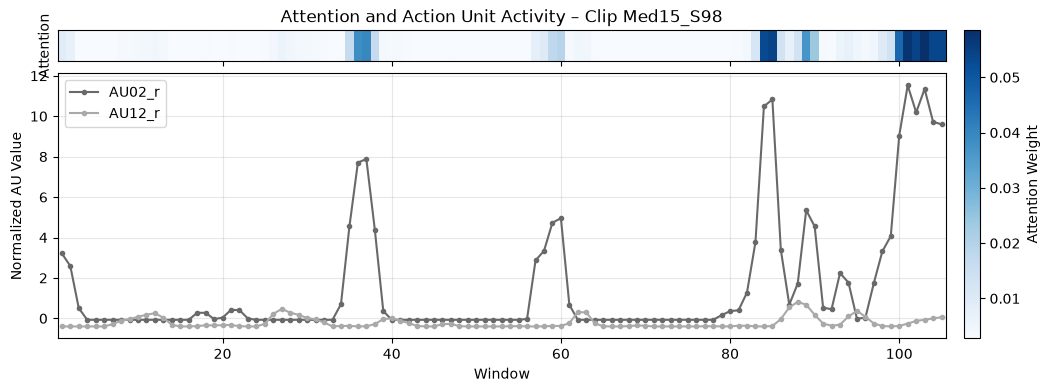

In [9]:
plot_attention_heatmap_with_two_au(true_positive_ex1)

# EXAMPLE FALSE POSITIVE

In [10]:
false_positives = [
    r for r in attention_results
    if r["true_label"] == 0 and r["pred_label"] == 1
]

false_positives_sorted = sorted(
    false_positives,
    key=lambda r: r["pred_prob"],
    reverse=True
)

for r in false_positives_sorted:
    print(f"{r["clip_id"]}:  {r["pred_prob"]}")

Pol2_S91:  0.9546335935592651
Pol2_S35:  0.9253923892974854
Pol2_S126:  0.9171056747436523
Pol2_S90:  0.8968891501426697
Med15_S51:  0.8930460810661316
Pol2_S10:  0.8789887428283691
Med15_S57:  0.833812952041626
Bus14_S65:  0.7659361958503723
Med15_S72:  0.736652672290802
Med15_S73:  0.735696017742157
Med15_S46:  0.7015506625175476
Med15_S71:  0.6682209372520447
Art6_S90:  0.640986979007721
Phi3_S108:  0.5832448601722717
Phi3_S42:  0.578701913356781
Phi3_S85:  0.5737768411636353
Tech21_S32:  0.5724061727523804
Phi3_S97:  0.5672022104263306
Tech21_S6:  0.5612743496894836
Pol9_S42:  0.5538504719734192
Tech21_S33:  0.5528479218482971
Tech21_S30:  0.5437666773796082
Med15_S81:  0.5429917573928833
Med15_S26:  0.5354413986206055
Art6_S43:  0.5343834161758423
Pol9_S15:  0.5219281911849976
Tech10_S58:  0.5160361528396606
Pol2_S93:  0.5129154920578003
Ent5_S19:  0.5027689933776855


In [11]:
false_positive_ex1 = df_attention[df_attention["clip_id"] == "Pol2_S91"]
false_positive_ex1

,clip_id,true_label,pred_prob,pred_label,attention,evidence,contribution,X
90,Pol2_S91,0,0.954634,1,"[0.010107943, 0.0072885384, 0.0064611617, 0.00...","[tensor(-0.1663), tensor(0.0574), tensor(0.060...","[tensor(-0.0017), tensor(0.0004), tensor(0.000...","[[0.3482143, 0.03815937], [0.3482143, 0.704826..."


In [12]:
top_attention_windows = top_windows(false_positive_ex1)
top_attention_windows.to_csv("../results/attention_heatmaps/false_positive_ex1.csv", float_format="%.4f")
top_attention_windows

,window,start_time_seconds,end_time_seconds,attention_weight,evidence,contribution
0,21,3.333333,3.666667,0.176340,3.780717,0.666691
1,25,4.000000,4.333333,0.174878,5.015347,0.877075
2,24,3.833333,4.166667,0.164283,4.316553,0.709136
3,22,3.500000,3.833333,0.121775,2.866785,0.349102
4,23,3.666667,4.000000,0.091221,2.629294,0.239848


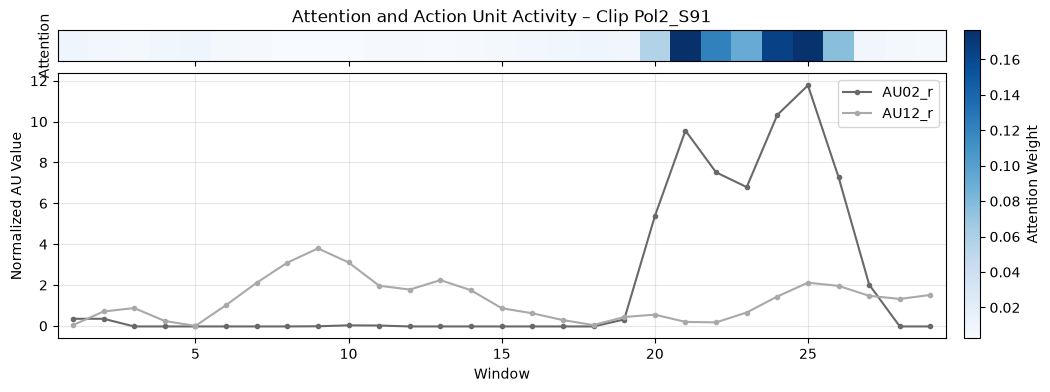

In [13]:
plot_attention_heatmap_with_two_au(false_positive_ex1)

# EXAMPLE TRUE NEGATIVE

In [14]:
true_negatives = [
    r for r in attention_results
    if r["true_label"] == 0 and r["pred_label"] == 0
]

true_negatives_sorted = sorted(
    true_negatives,
    key=lambda r: r["pred_prob"],
    reverse=False
)

for r in true_negatives_sorted:
    print(f"{r["clip_id"]}:  {r["pred_prob"]}")

Bus14_S28:  0.4103753864765167
Pol2_S49:  0.4264466464519501
Tech10_S2:  0.4282737970352173
Phi3_S171:  0.4314495623111725
Med15_S24:  0.43989285826683044
Bus14_S88:  0.44997063279151917
Med15_S70:  0.44998806715011597
Tech10_S62:  0.45370548963546753
Tech10_S57:  0.455874502658844
Tech21_S29:  0.4620077311992645
Ent5_S88:  0.46216464042663574
Edu2_S54:  0.4651169776916504
Med15_S99:  0.4753086268901825
Pol9_S17:  0.47934606671333313
Tech21_S3:  0.482102632522583
Med15_S23:  0.4829789400100708
Ent5_S33:  0.4831276834011078
Tech21_S5:  0.4835520088672638
Art6_S6:  0.48370057344436646
Tech21_S4:  0.48555323481559753
Ent5_S24:  0.4946894943714142
Pol9_S55:  0.49545955657958984
Art6_S89:  0.4985809326171875
Pol9_S97:  0.49914851784706116
Pol2_S9:  0.49999648332595825


In [15]:
true_negative_ex1 = df_attention[df_attention["clip_id"] == "Tech10_S2"]
true_negative_ex1

,clip_id,true_label,pred_prob,pred_label,attention,evidence,contribution,X
111,Tech10_S2,0,0.428274,0,"[0.12516111, 0.12157236, 0.13309664, 0.1335283...","[tensor(-0.3042), tensor(-0.3037), tensor(-0.2...","[tensor(-0.0381), tensor(-0.0369), tensor(-0.0...","[[0.027522936, -0.1381509], [0.27522936, -0.30..."


In [16]:
top_attention_windows = top_windows(true_negative_ex1)
top_attention_windows.to_csv("../results/attention_heatmaps/true_negative_ex1.csv", float_format="%.4f")
top_attention_windows

,window,start_time_seconds,end_time_seconds,attention_weight,evidence,contribution
0,4,0.500000,0.833333,0.133528,-0.224825,-0.030020
1,3,0.333333,0.666667,0.133097,-0.226870,-0.030196
2,1,0.000000,0.333333,0.125161,-0.304225,-0.038077
3,6,0.833333,1.166667,0.124815,-0.277481,-0.034634
4,5,0.666667,1.000000,0.124393,-0.280970,-0.034951


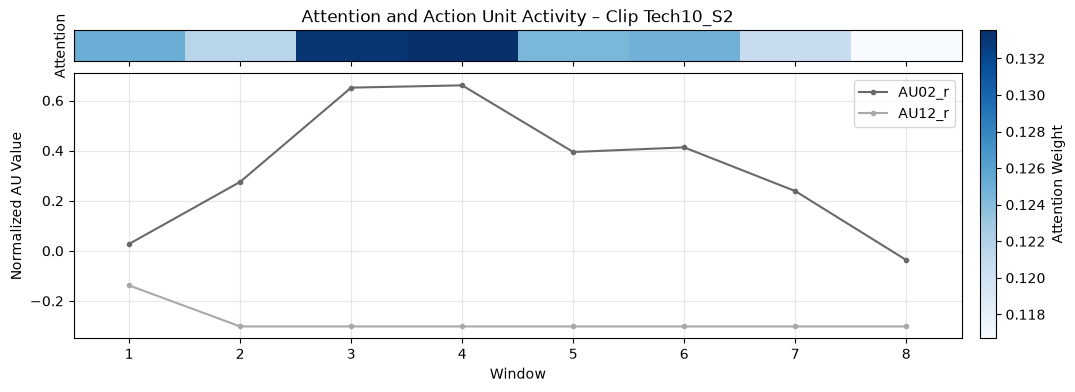

In [17]:
plot_attention_heatmap_with_two_au(true_negative_ex1)

# EXAMPLE FALSE NEGATIVE

In [18]:
false_negatives = [
    r for r in attention_results
    if r["true_label"] == 1 and r["pred_label"] == 0
]

false_negatives_sorted = sorted(
    false_negatives,
    key=lambda r: r["pred_prob"],
    reverse=False
)

for r in false_negatives_sorted:
    print(f"{r["clip_id"]}:  {r["pred_prob"]}")

Bus14_S108:  0.39085301756858826
Bus14_S106:  0.4094407558441162
Pol9_S101:  0.41697466373443604
Phi3_S129:  0.417310506105423
Tech10_S99:  0.44507330656051636
Edu2_S35:  0.4526037275791168
Tech21_S16:  0.46652716398239136
Pol2_S30:  0.4669121503829956
Pol9_S78:  0.4673019349575043
Tech10_S19:  0.46859994530677795
Edu2_S34:  0.4724312722682953
Tech21_S106:  0.4794146716594696
Ent5_S36:  0.4835878610610962
Pol2_S21:  0.4843284785747528
Tech10_S113:  0.4886787235736847
Ent5_S76:  0.492156982421875
Edu2_S77:  0.49421054124832153
Edu2_S51:  0.49493032693862915


In [19]:
false_negative_ex1 = df_attention[df_attention["clip_id"] == "Tech21_S16"]
false_negative_ex1

,clip_id,true_label,pred_prob,pred_label,attention,evidence,contribution,X
125,Tech21_S16,1,0.466527,0,"[0.05669824, 0.08470862, 0.07990268, 0.0540249...","[tensor(-0.2547), tensor(-0.1185), tensor(-0.1...","[tensor(-0.0144), tensor(-0.0100), tensor(-0.0...","[[0.34745762, -0.26217893], [1.1694915, -0.262..."


In [20]:
top_attention_windows = top_windows(false_negative_ex1)
top_attention_windows.to_csv("../results/attention_heatmaps/false_negative_ex1.csv", float_format="%.4f")
top_attention_windows

,window,start_time_seconds,end_time_seconds,attention_weight,evidence,contribution
0,2,0.166667,0.500000,0.084709,-0.118514,-0.010039
1,3,0.333333,0.666667,0.079903,-0.148495,-0.011865
2,7,1.000000,1.333333,0.063246,-0.237575,-0.015026
3,6,0.833333,1.166667,0.058480,-0.250762,-0.014665
4,1,0.000000,0.333333,0.056698,-0.254708,-0.014441


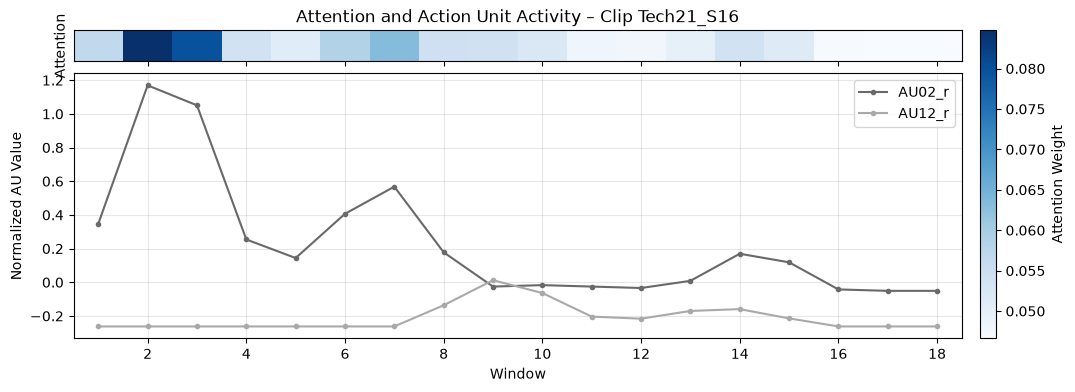

In [21]:
plot_attention_heatmap_with_two_au(false_negative_ex1)

# APPRAISAL STATISTICS

In [22]:
import pandas as pd

def appraisal_statistics(clip_ids, labels_path="../data/labels.csv"):
    labels = pd.read_csv(labels_path)

    selected = labels[labels["clip_id"].isin(clip_ids)].copy()
    missing = set(clip_ids) - set(selected["clip_id"])

    if missing:
        print(f"Warning: {len(missing)} clip(s) not found:")
        print(sorted(missing))

    stats = (
        selected["appraisal"]
        .value_counts(dropna=False)
        .rename_axis("appraisal")
        .reset_index(name="count")
    )

    print(f"Total clips: {len(selected)}")
    return stats

In [23]:
true_pos = []
false_neg = []

for pos in true_positives_sorted:
    true_pos.append(pos["clip_id"])
    
for neg in false_negatives_sorted:
    false_neg.append(neg["clip_id"])

In [24]:
print(appraisal_statistics(true_pos))

Total clips: 62
                appraisal  count
0               Judgement     27
1            Appreciation     19
2                  Affect     11
3  Judgement/Appreciation      2
4        Affect/Judgement      2
5     Affect/Appreciation      1


In [25]:
print(appraisal_statistics(false_neg))

Total clips: 18
      appraisal  count
0     Judgement     10
1  Appreciation      6
2        Affect      2
